# Week 5 — Decide (Lantern AI)

Milestone 5. First-choice league table, a fully specified lineup, 24-month NPV with tornado, the GPU rider call, a refreshed $p^*$, the launch experiment, and a student-plan verdict.

**Engine.** The Session 5 `Lantern_Lineup_Simulator_Template.xlsx` is not in the Capstone folder yet. This notebook implements Exhibits 2, 6, 7, 8 and Fact Pack tabs 1, 6, 7, 8. When the template lands, paste the take rates below into the yellow cells and confirm NPV direction. Untouched, the shipped template must show ≈ $1,706,251 — a different example lineup, not a target.

**Recommendation (first 60 seconds).** One paid tier: **Lantern Pro, $24/month**. Standard usage, Vault, life-admin with click-to-approve, full integrations, individual. Free keeps capped answers, standard privacy, no agents, no integrations, one seat. Annual: two months free; Fact Pack 30% mix. 24-month NPV **$1.36 million**. Do not buy the GPU rider; trigger is 15,500 paid seats. No verified-student plan.

Practice HB, RLH ≥ 0.45, n = 391, $m$ = take × 124,000. Swap `UTILITIES_PATH` when fielding closes.


## 0. Setup — first-choice engine, Bass, contribution NPV


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.power import NormalIndPower

sns.set_theme(style="whitegrid")

DATA_DIR = Path("Data")
UTILITIES_PATH = DATA_DIR / "Lantern_Practice_CBC_Data.xlsx"
FACT_PACK = DATA_DIR / "Lantern_Fact_Pack.xlsx"
POOL, DISC, P_BASS, Q_BASS, HORIZON = 124_000, 0.012, 0.035, 0.30, 24
FIXED0, EXTRA_TIER, RIDER = 95_000, 12_000, 22_000
CAP0, CAP_RIDER = 12_000, 50_000
USAGE_C = np.array([0.60, 2.20, 8.50])
AGENTS_C = np.array([0.00, 0.80, 4.20])
PRIV_C = np.array([0.00, 0.10, 1.20])
COL = {
    "usage": ["usage_1", "usage_2", "usage_3"],
    "priv": ["priv_1", "priv_2", "priv_3"],
    "agents": ["agents_1", "agents_2", "agents_3"],
    "integ": ["integ_1", "integ_2", "integ_3"],
    "seats": ["seats_1", "seats_2"],
}
LEVEL = {
    "usage": ["Light", "Standard", "Max"],
    "priv": ["Standard (may train)", "No-training", "Vault"],
    "agents": ["Answers", "Life-admin", "Autopilot"],
    "integ": ["None", "Email+cal", "Full suite"],
    "seats": ["Individual", "Household"],
}


def plan(usage, priv, agents, integ, seats, price, name):
    return dict(usage=usage, priv=priv, agents=agents, integ=integ, seats=seats, price=price, name=name)


def load_hb(path):
    u = pd.read_excel(path, sheet_name="Utilities")
    d = pd.read_excel(path, sheet_name="Demographics")
    keep = u.merge(d, on="Respondent_ID")
    keep = keep[keep.RLH >= 0.45].reset_index(drop=True)
    U = {c: keep[c].to_numpy() for cols in COL.values() for c in cols}
    U["price10"] = keep["Price_per_+$10"].to_numpy()
    U["NONE"] = keep["NONE"].to_numpy()
    return keep, U, keep["occupation"].to_numpy()


def plan_u(U, p):
    return (
        U[COL["usage"][p["usage"]]] + U[COL["priv"][p["priv"]]] + U[COL["agents"][p["agents"]]]
        + U[COL["integ"][p["integ"]]] + U[COL["seats"][p["seats"]]]
        + (p["price"] / 10) * U["price10"]
    )


def serving(p):
    s = USAGE_C[p["usage"]] + PRIV_C[p["priv"]] + AGENTS_C[p["agents"]]
    return float(s * (2.1 if p["seats"] else 1.0))


def monthly_churn(p):
    c = 0.07
    if p["agents"] == 2:
        c -= 0.015
    if p["integ"] == 2:
        c -= 0.008
    elif p["integ"] == 1:
        c -= 0.004
    if p["seats"]:
        c -= 0.010
    if p["priv"] == 2:
        c -= 0.003
    return max(0.028, c)


def economics(p, annual_discount=2 / 12):
    s = serving(p)
    support = 0.45 + (0.60 if p["seats"] else 0)
    price = p["price"]
    arpu = 0.70 * price + 0.30 * price * (1 - annual_discount)
    bill = 0.70 * (0.031 * price + 0.30) + 0.30 * ((0.031 * price * 12 * (1 - annual_discount) + 0.30) / 12)
    churn = 0.30 * 0.022 + 0.70 * monthly_churn(p)
    cm = arpu - s - support - bill
    return dict(serving=s, support=support, arpu=arpu, billing=bill, cm=cm, churn=churn)


def first_choice(U, occ, plans, student_only=None):
    util = np.vstack([plan_u(U, p) for p in plans] + [U["NONE"]])
    if student_only:
        util = util.copy()
        for j in student_only:
            util[j, occ != "student"] = -1e9
    pick = np.argmax(util, axis=0)
    n_plans = len(plans)
    takes = [(pick == j).mean() for j in range(n_plans)]
    none = (pick == n_plans).mean()
    by = {}
    for o in ["professional", "student", "other"]:
        m = occ == o
        by[o] = {plans[j]["name"]: float((pick[m] == j).mean()) for j in range(n_plans)}
        by[o]["None"] = float((pick[m] == n_plans).mean())
        by[o]["n"] = int(m.sum())
    return takes, none, by


def bass_adds(m, p=P_BASS, q=Q_BASS, T=HORIZON):
    t = np.arange(0, T + 1)
    pq = p + q
    F = (1 - np.exp(-pq * t)) / (1 + (q / p) * np.exp(-pq * t))
    F[0] = 0
    return m * np.diff(F)


def simulate(U, occ, plans, rider=False, rider_start=1, p=P_BASS, q=Q_BASS,
             take_mult=1.0, churn_shift=0.0, serving_mult=1.0, student_only=None):
    takes, none, by = first_choice(U, occ, plans, student_only=student_only)
    n_tiers = len(plans)
    ecos = [economics(pl) for pl in plans]
    for e in ecos:
        e["serving"] *= serving_mult
        e["cm"] = e["arpu"] - e["serving"] - e["support"] - e["billing"]
        e["churn"] = float(min(0.20, max(0.028, e["churn"] + churn_shift)))
    adds = [bass_adds(tk * take_mult * POOL, p, q) for tk in takes]
    stocks = [np.zeros(HORIZON) for _ in plans]
    for t in range(HORIZON):
        for k in range(n_tiers):
            prev = 0.0 if t == 0 else stocks[k][t - 1]
            stocks[k][t] = prev * (1 - ecos[k]["churn"]) + adds[k][t]
    total = np.sum(stocks, axis=0)
    contrib = np.zeros(HORIZON)
    spot = np.zeros(HORIZON)
    for t in range(HORIZON):
        cap = CAP_RIDER if (rider and (t + 1) >= rider_start) else CAP0
        rc = RIDER if (rider and (t + 1) >= rider_start) else 0
        over = max(0.0, total[t] - cap)
        if total[t] > 0 and over > 0:
            w = np.array([stocks[k][t] for k in range(n_tiers)]) / total[t]
            avg_s = sum(w[k] * ecos[k]["serving"] for k in range(n_tiers))
            spot[t] = over * 1.4 * avg_s
        var = sum(stocks[k][t] * ecos[k]["cm"] for k in range(n_tiers))
        contrib[t] = var - spot[t] - (FIXED0 + EXTRA_TIER * max(0, n_tiers - 1) + rc)
    disc = 1 / (1 + DISC) ** np.arange(1, HORIZON + 1)
    clv = []
    for e in ecos:
        surv = (1 - e["churn"]) ** np.arange(0, HORIZON)
        clv.append(float(np.sum(e["cm"] * surv / (1 + DISC) ** np.arange(1, HORIZON + 1))))
    return {
        "takes": takes, "none": none, "by": by, "npv": float((contrib * disc).sum()),
        "contrib": contrib, "total": total, "spot": spot, "stocks": stocks, "adds": adds,
        "ecos": ecos, "clv": clv, "names": [pl["name"] for pl in plans],
        "sub6": float(total[5]), "sub12": float(total[11]), "sub24": float(total[23]),
        "peak": float(total.max()), "peak_m": int(total.argmax() + 1),
    }


keep, U, occ = load_hb(UTILITIES_PATH)
print(f"Analytic n = {len(keep)}  (practice HB, RLH ≥ 0.45)")
print(f"Bass defaults p={P_BASS}, q={Q_BASS}  |  peak-adds month ln(q/p)/(p+q) = {np.log(Q_BASS/P_BASS)/(P_BASS+Q_BASS):.1f}")
print("Capacity: 12,000 seats treated as renewable inside the $95k platform cost for all 24 months.")
print("Dec 2027 contract end is a renewal event, not a drop to zero seats.")


Analytic n = 391  (practice HB, RLH ≥ 0.45)
Bass defaults p=0.035, q=0.3  |  peak-adds month ln(q/p)/(p+q) = 6.4
Capacity: 12,000 seats treated as renewable inside the $95k platform cost for all 24 months.
Dec 2027 contract end is a renewal event, not a drop to zero seats.


**p, q defense.** Freemium in-app paid launches are the closest analog (p 0.03–0.05, q 0.25–0.35). Course defaults sit in the middle. ChatGPT's 100M-in-two-months is an outlier, not a planning number. Required sensitivity is **q ± 40%**.

**Annual policy baked into CM.** Two months free (pay 10, get 12). 30% mix at 2.2%/month effective churn, 70% monthly at the feature-adjusted rate (Fact Pack tab 6). Blended ARPU = 0.95 × list.

**Spot.** Overage seats cost 2.4× serving instead of 1×, so **+1.4 × serving × overage**. Rider: +$22k/month, 50,000 seats, 12-month minimum, 30-day notice.


## 1. League table — eight lineups, first-choice


In [2]:
Clone = plan(1, 0, 0, 0, 0, 20, "Clone $20")
Pro24 = plan(1, 2, 1, 2, 0, 24, "Pro $24")
Pro20 = plan(1, 2, 1, 2, 0, 20, "Pro $20")
Pro16 = plan(1, 2, 1, 2, 0, 16, "Pro $16")
Home12 = plan(0, 1, 1, 1, 0, 12, "Home $12")
Home16 = plan(0, 1, 1, 1, 0, 16, "Home $16")
Plus20 = plan(1, 1, 1, 1, 0, 20, "Plus $20")
Plus16 = plan(1, 1, 1, 1, 0, 16, "Plus $16")
Max36 = plan(2, 2, 2, 2, 0, 36, "Max $36")
Stu12 = plan(0, 1, 1, 1, 0, 12, "Student $12")

specs = [
    ("Clone $20 (mandatory benchmark)", [Clone], False),
    ("Pro $24 — best single / RECOMMENDED", [Pro24], False),
    ("Pro $20 single", [Pro20], False),
    ("Pro $16 single", [Pro16], False),
    ("Home $12 + Pro $24", [Home12, Pro24], False),
    ("Home $16 + Pro $24", [Home16, Pro24], False),
    ("Plus $20 + Pro $24", [Plus20, Pro24], False),
    ("Home $12 + Pro $24 + Max $36", [Home12, Pro24, Max36], False),
    ("Pro $24 + rider from month 1 (capacity alt)", [Pro24], True),
]

rows = []
sims = {}
for label, plans, rider in specs:
    s = simulate(U, occ, plans, rider=rider)
    sims[label] = s
    take_s = " · ".join(f"{n} {t:.1%}" for n, t in zip(s["names"], s["takes"]))
    rows.append(
        {
            "lineup": label,
            "take": take_s,
            "none": s["none"],
            "m6": s["sub6"],
            "m12": s["sub12"],
            "m24": s["sub24"],
            "peak": s["peak"],
            "NPV": s["npv"],
        }
    )
league = pd.DataFrame(rows).sort_values("NPV", ascending=False)
print("First-choice × 124,000 → Bass m. Discount 1.2%/month. Near-ties within $150k are strategic ties.")
league.style.format(
    {"none": "{:.1%}", "m6": "{:,.0f}", "m12": "{:,.0f}", "m24": "{:,.0f}", "peak": "{:,.0f}", "NPV": "${:,.0f}"}
)


First-choice × 124,000 → Bass m. Discount 1.2%/month. Near-ties within $150k are strategic ties.


,lineup,take,none,m6,m12,m24,peak,NPV
1,Pro $24 — best single / RECOMMENDED,Pro $24 16.1%,83.9%,"7,308","13,248","9,285","13,376","$1,360,033"
6,Plus $20 + Pro $24,Plus $20 2.0% · Pro $24 14.6%,83.4%,"7,531","13,627","9,492","13,753","$1,127,233"
2,Pro $20 single,Pro $20 19.9%,80.1%,"9,048","16,402","11,495","16,561","$1,091,927"
5,Home $16 + Pro $24,Home $16 1.3% · Pro $24 15.1%,83.6%,"7,419","13,432","9,377","13,559","$1,080,038"
4,Home $12 + Pro $24,Home $12 6.6% · Pro $24 12.8%,80.6%,"8,787","15,847","10,915","15,982","$1,008,601"
8,Pro $24 + rider from month 1 (capacity alt),Pro $24 16.1%,83.9%,"7,308","13,248","9,285","13,376","$941,184"
7,Home $12 + Pro $24 + Max $36,Home $12 6.6% · Pro $24 12.0% · Max $36 1.8%,79.5%,"9,268","16,769","11,691","16,925","$927,548"
3,Pro $16 single,Pro $16 28.9%,71.1%,"13,109","23,762","16,653","23,992","$705,732"
0,Clone $20 (mandatory benchmark),Clone $20 1.0%,99.0%,457,809,522,812,"$-1,788,083"


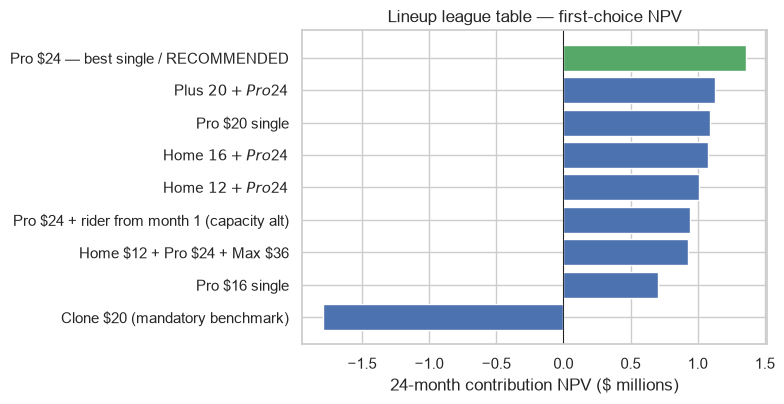

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot = league.sort_values("NPV")
ax.barh(plot["lineup"], plot["NPV"] / 1e6, color=["#55A868" if "RECOMMENDED" in n else "#4C72B0" for n in plot["lineup"]])
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("24-month contribution NPV ($ millions)")
ax.set_title("Lineup league table — first-choice NPV")
fig.tight_layout()


The $20 clone is not a near-tie. It takes 1.0% and destroys **$1.79 million** under $95k/month platform cost — Firefly again.

**Pro $24 is the best single tier and the best lineup.** Two-tier Home $12 + Pro $24 is $351k worse: the extra $12k/month complexity cost plus Home stealing Pro at a lower contribution margin. Plus $20 + Pro $24 is a red-bus pair (Plus take 2.0%). Three tiers add another $12k and still lose. Equivalence band is ±$150k; nothing else is inside it.


## 2. Recommendation, fully specified


In [4]:
rec = sims["Pro $24 — best single / RECOMMENDED"]
eco = rec["ecos"][0]
print("Lantern Pro — $24 / month")
print("  Usage:     Standard (unlimited fast, 25 advanced runs/mo)")
print("  Privacy:   Vault (no-training + on-device sensitive mode)   ← fence vs ChatGPT")
print("  Agents:    Life-admin, click-to-approve                     ← fence vs 'answers'")
print("  Integrate: Full suite (email, calendar, docs, storage, budgeting)")
print("  Seats:     Individual")
print("  Free:      capped answers, standard privacy (chats may train), no agents, no integrations, 1 seat")
print("  Annual:    2 months free (pay 10 get 12); plan on 30% mix")
print()
print(f"  Take {rec['takes'][0]:.1%}  none {rec['none']:.1%}  m = {rec['takes'][0]*POOL:,.0f} eventual adopters")
print(f"  ARPU ${eco['arpu']:.2f}  serving ${eco['serving']:.2f}  CM ${eco['cm']:.2f}/mo  blended churn {eco['churn']:.2%}")
print(f"  24-month discounted CLV ${rec['clv'][0]:.0f}")
print(f"  Subscribers  m6 {rec['sub6']:,.0f}  m12 {rec['sub12']:,.0f}  m24 {rec['sub24']:,.0f}  peak {rec['peak']:,.0f} in month {rec['peak_m']}")
print(f"  NPV ${rec['npv']:,.0f}")
print()
print("Take by occupation (why launch copy leads with professionals)")
for o, d in rec["by"].items():
    print(f"  {o:12s} n={d['n']:3d}  Pro {d['Pro $24']:.1%}  none {d['None']:.1%}")


Lantern Pro — $24 / month
  Usage:     Standard (unlimited fast, 25 advanced runs/mo)
  Privacy:   Vault (no-training + on-device sensitive mode)   ← fence vs ChatGPT
  Agents:    Life-admin, click-to-approve                     ← fence vs 'answers'
  Integrate: Full suite (email, calendar, docs, storage, budgeting)
  Seats:     Individual
  Free:      capped answers, standard privacy (chats may train), no agents, no integrations, 1 seat
  Annual:    2 months free (pay 10 get 12); plan on 30% mix

  Take 16.1%  none 83.9%  m = 19,980 eventual adopters
  ARPU $22.80  serving $4.20  CM $17.23/mo  blended churn 4.79%
  24-month discounted CLV $221
  Subscribers  m6 7,308  m12 13,248  m24 9,285  peak 13,376 in month 13
  NPV $1,360,033

Take by occupation (why launch copy leads with professionals)
  professional n=214  Pro 22.9%  none 77.1%
  student      n= 89  Pro 9.0%  none 91.0%
  other        n= 88  Pro 6.8%  none 93.2%


**The fence that does the work.** One paid tier, so the fence is versus free and versus the $20 incumbents: **Vault + life-admin**, not Max usage and not Autopilot. Week 4: life-admin vs answers median WTP $7.37 (100% positive); Vault vs standard $6.39; Autopilot vs life-admin $2.98 with 30% negative. Serving Autopilot costs $4.20. Leave it off the SKU.

**Hand-verify months 1–2.** $m = 0.1611 × 124,000 = 19,980. $F(t) = (1-e^{-0.335t})/(1+8.571 e^{-0.335t})$.
$F(1)=0.0399$ → adds 798. $F(2)=0.0907$ → adds 1,013. Stock$_2$ = 798 × (1−0.0479) + 1,013 = 1,773. Contribution$_1$ = 798 × $17.23 − $95,000 = −$81.3k.


In [5]:
m_star = rec["takes"][0] * POOL
F1 = (1 - np.exp(-(P_BASS + Q_BASS))) / (1 + (Q_BASS / P_BASS) * np.exp(-(P_BASS + Q_BASS)))
adds1 = m_star * F1
print(f"m={m_star:,.1f}  F(1)={F1:.4f}  adds1={adds1:,.1f}  stock1={rec['total'][0]:,.1f}  contrib1=${rec['contrib'][0]:,.0f}")
print(f"stock2={rec['total'][1]:,.1f}  contrib2=${rec['contrib'][1]:,.0f}")
assert abs(adds1 - rec["total"][0]) < 1


m=19,979.5  F(1)=0.0399  adds1=797.5  stock1=797.5  contrib1=$-81,262
stock2=1,773.1  contrib2=$-64,457


### Tornado (≥ 5 drivers) — Pro $24


Base NPV $1,360,033. Equivalence band ±$150k.


,driver,NPV,delta,peak
0,Take rate −25%,"$555,479","$-804,554","10,032"
4,Buy rider month 1,"$941,184","$-418,849","13,376"
2,q −40% (required),"$961,514","$-398,519","11,675"
5,Churn +1 pp,"$1,157,871","$-202,162","12,626"
7,Serving +20%,"$1,188,259","$-171,774","13,376"
8,p = 0.025,"$1,201,869","$-158,164","13,153"
9,p = 0.05,"$1,515,574","$155,541","13,655"
3,q +40% (required),"$1,554,363","$194,330","14,477"
6,Churn −1 pp,"$1,566,787","$206,754","14,226"
1,Take rate +25%,"$2,012,403","$652,370","16,720"


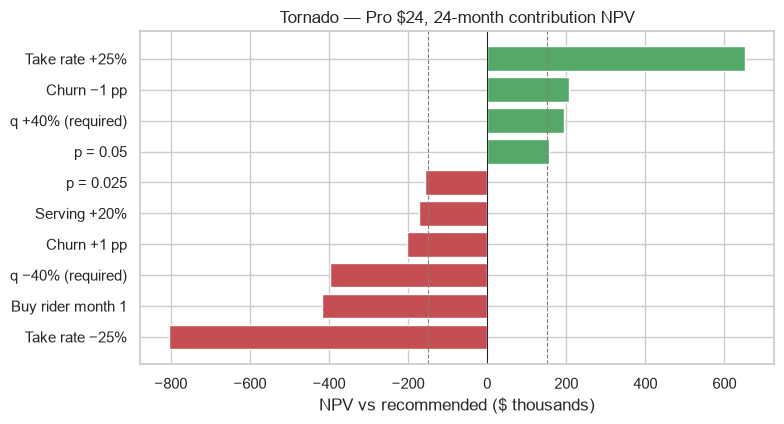

In [6]:
base_npv = rec["npv"]
tornado_specs = [
    ("Take rate −25%", dict(take_mult=0.75)),
    ("Take rate +25%", dict(take_mult=1.25)),
    ("q −40% (required)", dict(q=Q_BASS * 0.6)),
    ("q +40% (required)", dict(q=Q_BASS * 1.4)),
    ("Buy rider month 1", dict(rider=True, rider_start=1)),
    ("Churn +1 pp", dict(churn_shift=0.01)),
    ("Churn −1 pp", dict(churn_shift=-0.01)),
    ("Serving +20%", dict(serving_mult=1.2)),
    ("p = 0.025", dict(p=0.025)),
    ("p = 0.05", dict(p=0.05)),
]
torn_rows = []
for name, kw in tornado_specs:
    s = simulate(U, occ, [Pro24], **kw)
    torn_rows.append({"driver": name, "NPV": s["npv"], "delta": s["npv"] - base_npv, "peak": s["peak"]})
torn = pd.DataFrame(torn_rows).sort_values("delta")
print(f"Base NPV ${base_npv:,.0f}. Equivalence band ±$150k.")
fig, ax = plt.subplots(figsize=(8, 4.4))
colors = ["#C44E52" if d < 0 else "#55A868" for d in torn["delta"]]
ax.barh(torn["driver"], torn["delta"] / 1e3, color=colors)
ax.axvline(0, color="black", linewidth=0.6)
ax.axvline(-150, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(150, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("NPV vs recommended ($ thousands)")
ax.set_title("Tornado — Pro $24, 24-month contribution NPV")
fig.tight_layout()
torn.style.format({"NPV": "${:,.0f}", "delta": "${:,.0f}", "peak": "{:,.0f}"})


What would change our mind: take rate 25% below the conjoint (NPV $0.56M) or a world that needs the rider at month 1 (NPV $0.94M). q ± 40% stays inside or near the $150k band on the high side and $399k on the low side — word-of-mouth is the second-largest risk, which is why the launch experiment is about conversion, not about p.


## 3. Capacity call


In [7]:
s_spot = rec
s_rider = simulate(U, occ, [Pro24], rider=True, rider_start=1)
spot_annuity = float(np.sum(s_spot["spot"] / (1 + DISC) ** np.arange(1, HORIZON + 1)))
print("Committed 12,000 seats for 24 months (renewal inside $95k).")
print(f"Peak stock {s_spot['peak']:,.0f} in month {s_spot['peak_m']}  —  {s_spot['peak']-CAP0:,.0f} over the cap")
print(f"Spot extra (undiscounted sum) ${s_spot['spot'].sum():,.0f}  discounted ${spot_annuity:,.0f}")
print(f"NPV absorb spot  ${s_spot['npv']:,.0f}")
print(f"NPV buy rider m1 ${s_rider['npv']:,.0f}  (worse by ${s_spot['npv']-s_rider['npv']:,.0f})")
print()
S = eco["serving"]
be_over = RIDER / (1.4 * S)
print(f"Rider vs spot breakeven overage = $22,000 / (1.4 × ${S:.2f}) = {be_over:,.0f} seats")
print(f"Trigger stock = 12,000 + {be_over:,.0f} = {CAP0 + be_over:,.0f}")
print()
cap_tbl = pd.DataFrame(
    {
        "month": np.arange(1, 25),
        "subscribers": s_spot["total"],
        "spot_$": s_spot["spot"],
        "contrib_$": s_spot["contrib"],
        "over_12k": np.maximum(s_spot["total"] - CAP0, 0),
    }
)
cap_tbl.loc[[0, 5, 8, 9, 11, 12, 17, 23]].style.format(
    {"subscribers": "{:,.0f}", "spot_$": "${:,.0f}", "contrib_$": "${:,.0f}", "over_12k": "{:,.0f}"}
)


Committed 12,000 seats for 24 months (renewal inside $95k).
Peak stock 13,376 in month 13  —  1,376 over the cap
Spot extra (undiscounted sum) $44,136  discounted $37,563
NPV absorb spot  $1,360,033
NPV buy rider m1 $941,184  (worse by $418,849)

Rider vs spot breakeven overage = $22,000 / (1.4 × $4.20) = 3,741 seats
Trigger stock = 12,000 + 3,741 = 15,741



,month,subscribers,spot_$,contrib_$,over_12k
0,1,798,$0,"$-81,262",0
5,6,"7,308",$0,"$30,892",0
8,9,"11,370",$0,"$100,855",0
9,10,"12,270","$1,590","$114,776",270
11,12,"13,248","$7,338","$125,867","1,248"
12,13,"13,376","$8,093","$127,324","1,376"
17,18,"12,021",$123,"$111,945",21
23,24,"9,285",$0,"$64,935",0


**Do not buy the rider at launch.** Peak overage is ~1,400 seats; the rider needs ~3,740 overage seats before $22k/month beats 2.4× spot. Months 10–18 nibble spot at $0.1–8k/month.

**Trigger (observable).** If paid seats are on a path to **15,500** — specifically, month-8 stock > 12,500 or a 4-week run-rate that would cross 15,500 within 60 days — give 30-day notice and activate the rider. Take +25% in the tornado peaks at 16,720, which is the scenario that flips the call. Until then, absorb spot.


## 4. Refresh $p^*$ with our CLV

Week 2 used planning $V = \$24.70$. Substituting raw CLV (\$221) treats a banner click as a sure \$221 subscriber and drops $p^*$ to 1.5% — show everyone, which Week 2 already proved loses money at the old V.

The Fact Pack definition is contribution *per unit of P(intent)*. Intent is a click, not a paid conversion. Bridge: a certain-intent user is a qualified-pool analogue, of whom the conjoint says 16.1% pay, each worth \$221.

$$
V = \text{CLV} \times \text{take} = \$221 \times 16.1\% = \$35.62
\qquad
p^* = 3.40 / 35.62 = 9.5\%
$$


In [8]:
tele = pd.read_excel(FACT_PACK, sheet_name="3_Free_User_Telemetry")
num = [
    "tenure_months", "sessions_per_week", "avg_msgs_per_session", "agent_preview_uses_30d",
    "doc_uploads_30d", "privacy_mode_share", "household_shared_device", "referred_by_friend",
]
X = pd.concat([tele[num], pd.get_dummies(tele[["platform", "occupation"]], drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X.astype(float), has_constant="add")
logit = sm.Logit(tele["upgrade_intent_click"].astype(float), X).fit(disp=False)
p_int = logit.predict(X)
C_OFFER = 3.40
V_plan, V_clv, V_own = 24.70, rec["clv"][0], rec["clv"][0] * rec["takes"][0]
scale = 400_000 / len(tele)

def offer_econ(V, label):
    pstar = C_OFFER / V
    elig = p_int >= pstar
    ev = p_int * V - C_OFFER
    return {
        "rule": label,
        "V": V,
        "p*": pstar,
        "n_400k": elig.mean() * 400_000,
        "targeted_$": ev[elig].sum() * scale,
        "everyone_$": ev.sum() * scale,
    }

econ = pd.DataFrame(
    [
        offer_econ(V_plan, "Week 2 planning V"),
        offer_econ(V_own, "CLV × take (recommended)"),
        offer_econ(V_clv, "Raw CLV (too aggressive)"),
    ]
)
print("Show the $15 credit iff P(intent) ≥ p*. Lead messaging: professionals (22.9% Pro take vs 9.0% students).")
econ.style.format({"V": "${:.2f}", "p*": "{:.1%}", "n_400k": "{:,.0f}", "targeted_$": "${:,.0f}", "everyone_$": "${:,.0f}"})


Show the $15 credit iff P(intent) ≥ p*. Lead messaging: professionals (22.9% Pro take vs 9.0% students).


,rule,V,p*,n_400k,targeted_$,everyone_$
0,Week 2 planning V,$24.70,13.8%,"102,320","$190,203","$-387,808"
1,CLV × take (recommended),$35.62,9.5%,"163,200","$471,824","$42,051"
2,Raw CLV (too aggressive),$221.08,1.5%,"397,200","$7,342,417","$7,341,619"


## 5. Launch experiment


In [9]:
power = NormalIndPower()


def n_arm(p1, p0, alpha=0.05, pow=0.80):
    h = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0))
    return float(power.solve_power(effect_size=abs(h), power=pow, alpha=alpha, ratio=1))


power_tbl = pd.DataFrame(
    [
        {"contrast": "Pro 16% vs clone 1% (conjoint)", "p1": 0.161, "p0": 0.010, "n_arm": n_arm(0.161, 0.010)},
        {"contrast": "Pro 16% vs 8% (half the conjoint)", "p1": 0.161, "p0": 0.080, "n_arm": n_arm(0.161, 0.080)},
        {"contrast": "10% vs 5% (conservative MDE)", "p1": 0.100, "p0": 0.050, "n_arm": n_arm(0.100, 0.050)},
    ]
)
print("Eligible traffic at p* = 9.5%: 163,200 of 400,000 MAU.")
print("Sept banner reached the whole base in a week → >> 848 needed. Runtime is 7 days by design, not by sample.")
power_tbl.style.format({"p1": "{:.1%}", "p0": "{:.1%}", "n_arm": "{:,.0f}"})


Eligible traffic at p* = 9.5%: 163,200 of 400,000 MAU.
Sept banner reached the whole base in a week → >> 848 needed. Runtime is 7 days by design, not by sample.


,contrast,p1,p0,n_arm
0,Pro 16% vs clone 1% (conjoint),16.1%,1.0%,40
1,Pro 16% vs 8% (half the conjoint),16.1%,8.0%,247
2,10% vs 5% (conservative MDE),10.0%,5.0%,424


**Hypothesis.** Eligible users (P(intent) ≥ 9.5%) convert to paid within 14 days at ≥ 8% on the Pro $24 page, versus ≤ 3% on a $20 incumbent-clone page. (Riskiest tornado driver: take −25%.)

**Design.** 1:1 RCT, in-app plan page, among users who clear $p^*$. No other credit difference; both arms see the $15 launch offer if they convert. Pre-register: no peeking after 48 hours except a futility bound.

**Primary metric.** 14-day paid conversion (binary). Not clicks, not NPS.

**Powered n.** 424 per arm detects 10% vs 5% at 80% / 5%. That is the conservative MDE; the conjoint 16% vs 1% needs 40/arm and would be an unethical under-power excuse.

**Runtime.** 7 days at Fact Pack MAU traffic. 163k eligible; even 5% weekly reach is ~8,000, 9× the 848.

**Decision rule.** Ship Pro $24 if treatment 14-day conversion ≥ 8% **and** lift versus clone ≥ +4 pp. If treatment < 5%, do not launch paid; return to fences (Firefly replay). If 5–8%, extend 7 days and re-evaluate. Do not “average in” the clone as a second SKU — the league table already killed it.


## 6. Verified-student plan — cannibalization and capacity


In [10]:
s_no = rec
s_st = simulate(U, occ, [Pro24, Stu12], student_only={1})
print("Verified = only occupation==student may choose Student $12. Professionals cannot.")
print()
print(f"Pro only          NPV ${s_no['npv']:,.0f}  peak {s_no['peak']:,.0f}  Pro take {s_no['takes'][0]:.1%}")
print(f"Pro + Student $12 NPV ${s_st['npv']:,.0f}  peak {s_st['peak']:,.0f}  Pro {s_st['takes'][0]:.1%}  Student {s_st['takes'][1]:.1%}")
print(f"Delta NPV ${s_st['npv']-s_no['npv']:,.0f}  extra seats {s_st['peak']-s_no['peak']:,.0f}  extra tier cost $12k/mo")
print()
print("Students without student SKU:  Pro", f"{s_no['by']['student']['Pro $24']:.1%}")
print("Students with student SKU:     Pro", f"{s_st['by']['student']['Pro $24']:.1%}",
      " Student", f"{s_st['by']['student']['Student $12']:.1%}")
print("Professionals (verified, so unchanged):", f"{s_no['by']['professional']['Pro $24']:.1%}")
print()
print(f"Student CM ${s_st['ecos'][1]['cm']:.2f}/mo vs Pro CM ${s_st['ecos'][0]['cm']:.2f}/mo")
print(f"Among students, {s_no['by']['student']['Pro $24']-s_st['by']['student']['Pro $24']:.1%} pp leave Pro for the $12 SKU (cannibalization).")
print(f"New student converts: {s_st['by']['student']['Student $12'] - (s_no['by']['student']['Pro $24']-s_st['by']['student']['Pro $24']):.1%} pp.")


Verified = only occupation==student may choose Student $12. Professionals cannot.

Pro only          NPV $1,360,033  peak 13,376  Pro take 16.1%
Pro + Student $12 NPV $1,123,246  peak 14,390  Pro 15.3%  Student 2.0%
Delta NPV $-236,787  extra seats 1,014  extra tier cost $12k/mo

Students without student SKU:  Pro 9.0%
Students with student SKU:     Pro 5.6%  Student 9.0%
Professionals (verified, so unchanged): 22.9%

Student CM $8.88/mo vs Pro CM $17.23/mo
Among students, 3.4% pp leave Pro for the $12 SKU (cannibalization).
New student converts: 5.6% pp.


**No.** NPV falls ~$237k — outside the $150k equivalence band — because (1) a second tier costs $12k/month, (2) 3.4 pp of students trade $17.23 CM for $8.88 CM, and (3) the new 5.6 pp of student converts plus cannibals add ~1,000 peak seats, closer to the rider trigger, for a thin margin. Professionals are unchanged under a true verified fence, so this is not a “maybe the mix helps.” Ship one SKU. Revisit a student price in year 2 if Pro is capacity-constrained and needs a relief valve, not a growth engine.


## Memo copy-paste

**Lineup.** One paid tier: Lantern Pro $24/month — Standard usage, Vault, life-admin (click-to-approve), full suite, individual. Free: capped answers, standard privacy, no agents, no integrations, one seat. Annual: two months free; 30% mix. Fence that does the work: Vault + life-admin versus free and versus the $20 clone.

**League (first-choice, n = 391, × 124,000, p = 0.035, q = 0.30).** Pro $24 NPV **$1.36M**, take 16.1%, subscribers 7.3k / 13.2k / 9.3k at months 6/12/24. Clone $20: take 1.0%, NPV −$1.79M. Next-best two-tier (Plus $20 + Pro $24) $1.13M with Plus at 2% — not a real second SKU. Home $12 + Pro $24 $1.01M.

**Capacity.** Do not buy the $22k rider. Peak 13,376 in month 13; spot extra is cheap (~$8k at peak) versus $22k. Trigger: paid seats on a path to 15,500 (breakeven overage ≈ 3,740 at $4.20 serving). 30-day notice.

**Targeting.** $V = \$221 \times 16.1\% = \$35.62$. $p^* = 9.5\%$. **163,200** of 400,000 see the $15 credit. Targeted expected profit **+$472k** vs +$42k show-everyone. Lead with professionals (22.9% take).

**Experiment.** Eligible-user RCT, Pro $24 page vs $20 clone, primary 14-day paid conversion, n = 424/arm (10% vs 5%), 7 days, ship if treatment ≥ 8% and +4 pp vs clone.

**Student plan.** No. −$237k NPV, 3.4 pp cannibalized from Pro to $12, +1,000 peak seats, +$12k/month complexity.
